In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd 'drive/MyDrive/AI와 기후변화 (2025)/4주차 (250923)'

/content/drive/MyDrive/AI와 기후변화 (2025)/4주차 (250923)


In [ ]:
import os
print(os.getcwd())

/content/drive/MyDrive/AI와 기후변화 (2025)/4주차 (250923)


In [ ]:
data = pd.read_csv('./data/asos003_SQM_ACCESS-CM2_ssp585.csv')

# YR, MM, DD를 문자열로 만들기
data['YR'] = [str(x) for x in data['YR']]
# 1, 2, 3과 같이 되어 있는 경우 01, 02, 03으로 바꾸기
data['MM'] = [str(x).zfill(2) for x in data['MM']]
data['DD'] = [str(x).zfill(2) for x in data['DD']]

# 연도별, 월별 합계 구하기 -> 월 강수량(mm)을 구하기 위해 적용
data  = data.groupby(by=['YR', 'MM']).sum()
data = data.reset_index()

# YYYY-MM의 꼴을 만들기 위해 YR과 MM 사용
data['Date'] = data['YR'] + '-' + data['MM']
data.index = pd.to_datetime(data['Date'])
data = data[['PCP']]
data

,PCP
Date,
2011-01-01,3.995873
2011-02-01,4.347991
2011-03-01,5.213588
2011-04-01,47.391880
2011-05-01,22.971377
...,...
2100-08-01,688.434190
2100-09-01,2.709942
2100-10-01,0.517549


In [ ]:
# SPI 패키지 적용
# 가뭄지수 산정을 위한 라이브러리 패키지 설치
!pip install spei

# 설치 완료 후 패키지 import
import spei

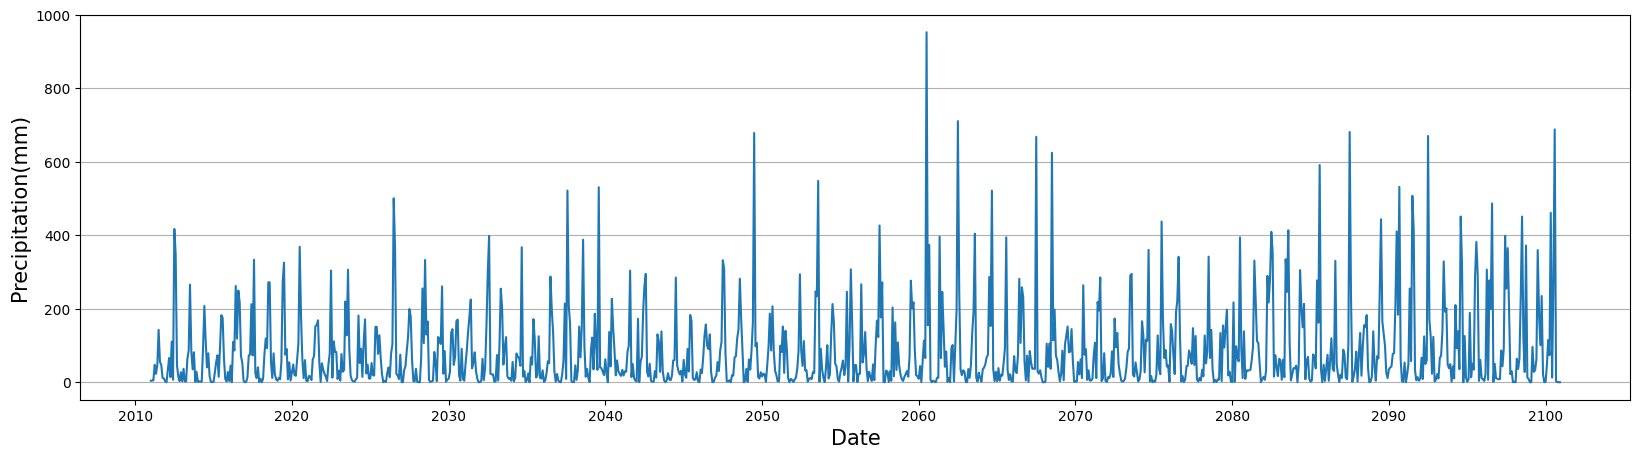

In [ ]:
# 강수량 시각화
plt.figure(figsize=(20,5))
plt.plot(data.index, data['PCP'])
plt.grid(axis='y')
plt.ylabel('Precipitation(mm)', fontsize=15)
plt.xlabel('Date', fontsize=15)
plt.show()

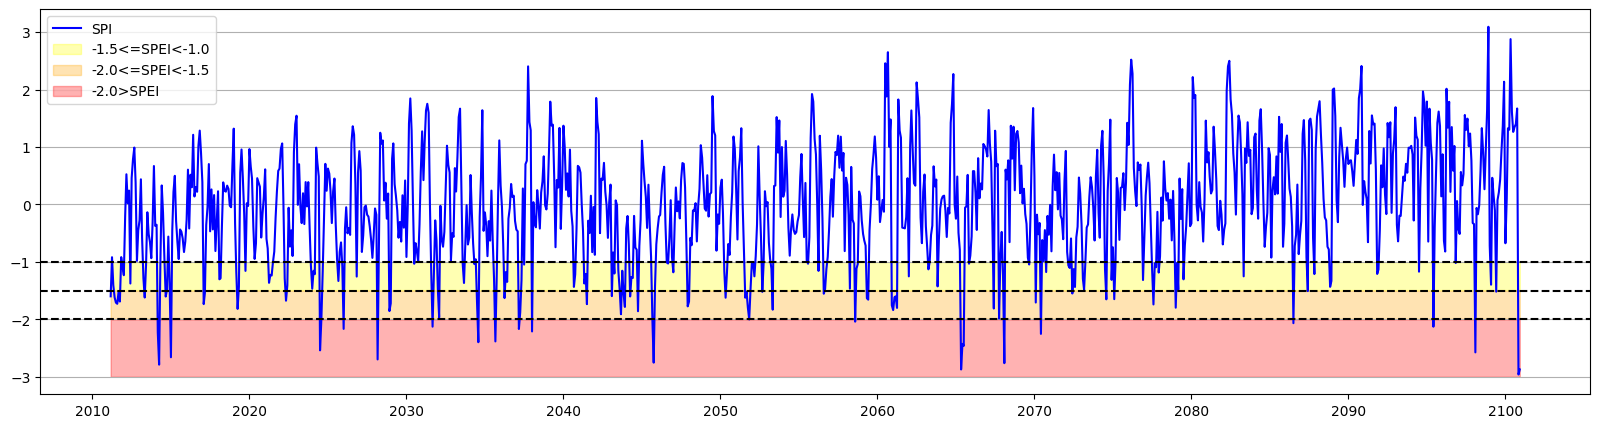

In [ ]:
# SPI-3 산정

scale = 3

precip = data['PCP']
spi_result = spei.spi(precip, timescale=scale)

fig, ax = plt.subplots(figsize=(20, 5))

# SPI 그래프
ax.plot(spi_result.index, spi_result.values, label='SPI', color='blue')

# 구간 표시
ax.axhline(-1.0, color='black', linestyle='--')
ax.axhline(-1.5, color='black', linestyle='--')
ax.axhline(-2.0, color='black', linestyle='--')

# 심각단계 현
ax.fill_between(spi_result.index, -1.49, -1.00, color='yellow', alpha=0.3, label='-1.5<=SPEI<-1.0')
ax.fill_between(spi_result.index, -1.99, -1.50, color='orange', alpha=0.3, label='-2.0<=SPEI<-1.5')
ax.fill_between(spi_result.index, -3.0, -2.00, color='red', alpha=0.3, label='-2.0>SPEI')

plt.grid(axis='y')
plt.legend()
plt.show()

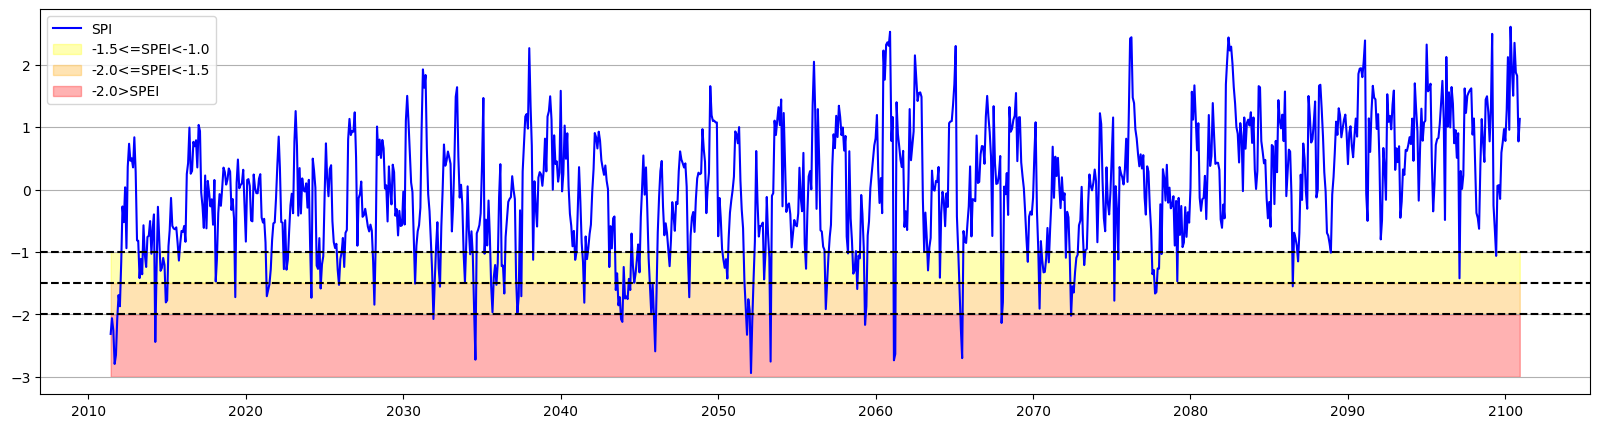

In [ ]:
# SPI-6 산정

scale = 6

precip = data['PCP']
spi_result = spei.spi(precip, timescale=scale)

fig, ax = plt.subplots(figsize=(20, 5))

# SPI 그래프
ax.plot(spi_result.index, spi_result.values, label='SPI', color='blue')

# 구간 표시
ax.axhline(-1.0, color='black', linestyle='--')
ax.axhline(-1.5, color='black', linestyle='--')
ax.axhline(-2.0, color='black', linestyle='--')

# 심각단계 현
ax.fill_between(spi_result.index, -1.49, -1.00, color='yellow', alpha=0.3, label='-1.5<=SPEI<-1.0')
ax.fill_between(spi_result.index, -1.99, -1.50, color='orange', alpha=0.3, label='-2.0<=SPEI<-1.5')
ax.fill_between(spi_result.index, -3.0, -2.00, color='red', alpha=0.3, label='-2.0>SPEI')

plt.grid(axis='y')
plt.legend()
plt.show()

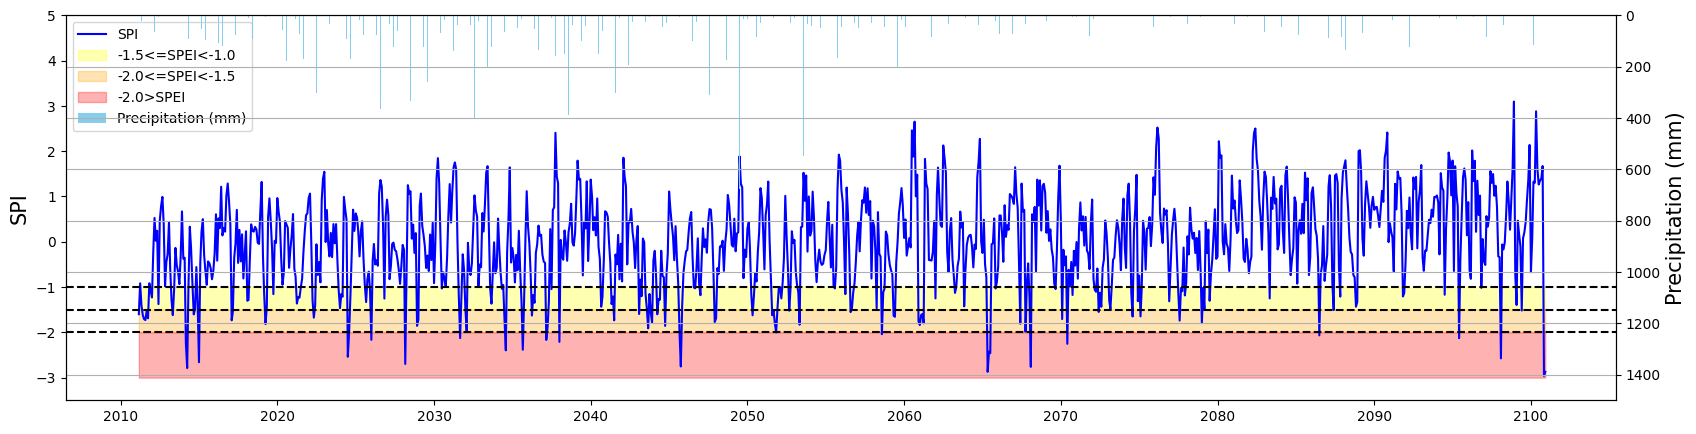

In [ ]:
# SPI-3 산정

scale = 3

precip = data['PCP']
spi_result = spei.spi(precip, timescale=scale)

fig, ax = plt.subplots(figsize=(20, 5))

# SPI 그래프
ax.plot(spi_result.index, spi_result.values, label='SPI', color='blue')

# 구간 표시
ax.axhline(-1.0, color='black', linestyle='--')
ax.axhline(-1.5, color='black', linestyle='--')
ax.axhline(-2.0, color='black', linestyle='--')

# 심각단계 표현
ax.fill_between(spi_result.index, -1.49, -1.00, color='yellow', alpha=0.3, label='-1.5<=SPEI<-1.0')
ax.fill_between(spi_result.index, -1.99, -1.50, color='orange', alpha=0.3, label='-2.0<=SPEI<-1.5')
ax.fill_between(spi_result.index, -3.0, -2.00, color='red', alpha=0.3, label='-2.0>SPEI')

ax.set_ylim(-3.5, 5)
ax.set_ylabel('SPI', fontsize=15)

# 보조축 생성 (강수량)
ax2 = ax.twinx()
ax2.bar(precip.index, precip.values, color='skyblue', width=3, alpha=1, label='Precipitation (mm)')
ax2.set_ylabel('Precipitation (mm)', fontsize=15)
ax2.set_ylim(0, 1500)
ax2.invert_yaxis()   # Y축 반전 (거꾸로 표시)

plt.grid(axis='y')

lns1, labs1 = ax.get_legend_handles_labels()
lns2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lns1+lns2, labs1+labs2)

plt.show()

/tmp/ipython-input-1295717018.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['PCP'] = data['PCP'].fillna(method='ffill')


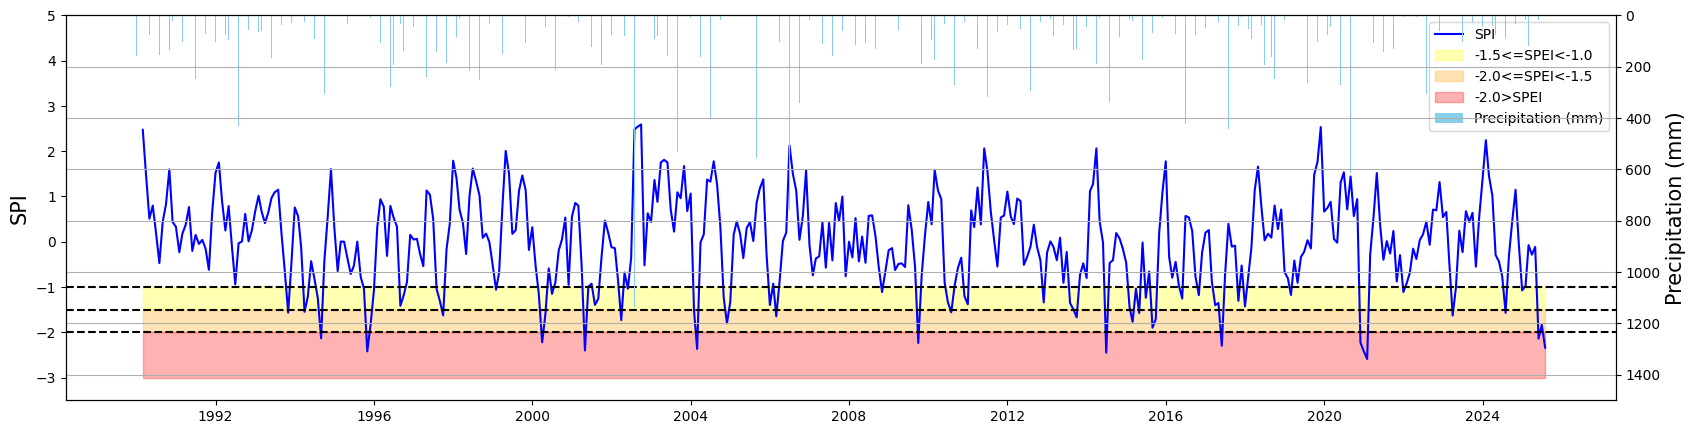

In [ ]:
# 과거 관측 데이터 적용 (강릉)

data = pd.read_csv('./data/ASOS_105_강릉.csv')
data['일시'] = pd.to_datetime(data['일시'])
data = data[['일시', '월합강수량(00~24h만)(mm)']]
data.columns = ['Date', 'PCP']
data.index = data['Date']
data['PCP'] = data['PCP'].fillna(method='ffill')


############### ASOS 관측 데이터를 이용하여 1990-01 ~ 2025.08의 SPI-3를 산정 후, 2024-01 ~ 2025-08 기간을 시각화 ##################################